Descargando SOL/USDT...
Descargando JUP/USDT...
Descargando JTO/USDT...
Descargando PYTH/USDT...
Descargando WIF/USDT...

Datos alineados: 1000 horas.

--- RESULTADOS DEL TORNEO ---
PAR             | CORRELACIÓN  | COINTEGRACIÓN (p-value)   | VEREDICTO
----------------------------------------------------------------------
JUP/USDT        | 0.8326       | 0.178761                  | ❌ DESCARTADO
JTO/USDT        | 0.7871       | 0.173947                  | ❌ DESCARTADO
PYTH/USDT       | 0.6972       | 0.510806                  | ❌ DESCARTADO
WIF/USDT        | 0.9296       | 0.764243                  | ❌ DESCARTADO


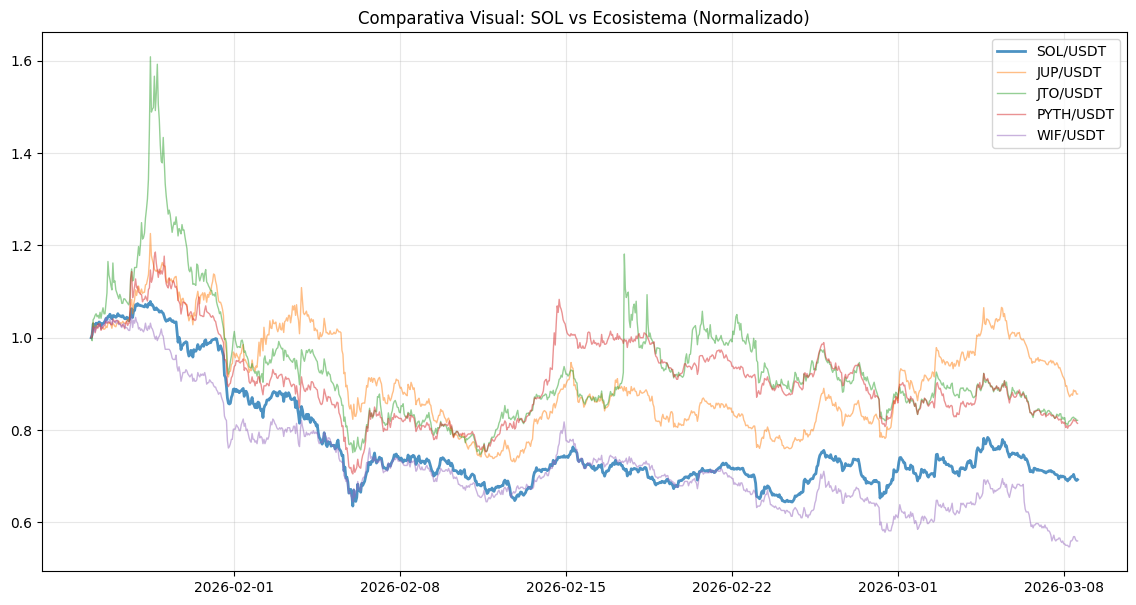

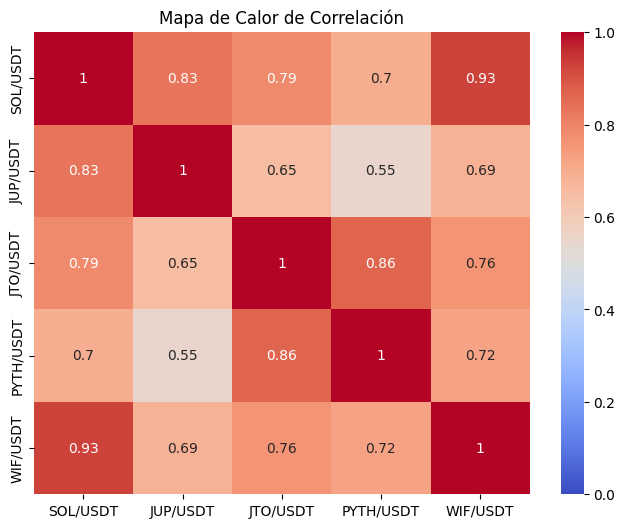

In [1]:
import ccxt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# 1. CONFIGURACIÓN
EXCHANGE = ccxt.binance()
TIMEFRAME = '1h'
LIMIT = 1000 # Velas por petición (Binance suele dar 1000 máx)
# Candidatos a "Pareja de Baile" de SOL
PAIRS = ['SOL/USDT', 'JUP/USDT', 'JTO/USDT', 'PYTH/USDT', 'WIF/USDT']

def fetch_data(symbol):
    print(f"Descargando {symbol}...")
    # Bajamos datos recientes (últimas 1000 horas, aprox 40 días)
    # Para un análisis más profundo se necesitaría paginación, pero esto sirve de 'catas'.
    ohlcv = EXCHANGE.fetch_ohlcv(symbol, timeframe=TIMEFRAME, limit=LIMIT)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df['close']

# 2. OBTENCIÓN DE DATOS
df_main = pd.DataFrame()

try:
    for pair in PAIRS:
        df_main[pair] = fetch_data(pair)
except Exception as e:
    print(f"Error descargando (asegúrate de tener internet): {e}")

# Limpiamos huecos
df_main = df_main.dropna()
print(f"\nDatos alineados: {len(df_main)} horas.")

# 3. ANÁLISIS CUANTITATIVO
target = 'SOL/USDT'
candidates = [c for c in PAIRS if c != target]

results = []

print("\n--- RESULTADOS DEL TORNEO ---")
print(f"{'PAR':<15} | {'CORRELACIÓN':<12} | {'COINTEGRACIÓN (p-value)':<25} | {'VEREDICTO'}")
print("-" * 70)

for candidate in candidates:
    # A. Correlación (Pearson)
    # Mide si suben/bajan a la vez. 1.0 es perfecto.
    corr = df_main[target].corr(df_main[candidate])
    
    # B. Cointegración (Engle-Granger Test)
    # Mide si el ratio es estacionario (mean reverting).
    # score: estadístico t. pvalue: probabilidad.
    # Queremos pvalue < 0.05 para decir que están cointegrados (95% confianza).
    score, pvalue, _ = coint(df_main[target], df_main[candidate])
    
    veredicto = "✅ GANADOR" if (corr > 0.8 and pvalue < 0.05) else "❌ DESCARTADO"
    if 0.05 < pvalue < 0.15: veredicto = "⚠️ POSIBLE"
    
    results.append({
        'Par': candidate,
        'Corr': corr,
        'P-Value': pvalue
    })
    
    print(f"{candidate:<15} | {corr:.4f}       | {pvalue:.6f}                  | {veredicto}")

# 4. VISUALIZACIÓN DE LOS RATIOS (Normalizados)
plt.figure(figsize=(14, 7))
for col in df_main.columns:
    # Normalizamos a 1 para que empiecen igual y ver la divergencia visual
    normalized_price = df_main[col] / df_main[col].iloc[0]
    plt.plot(normalized_price, label=col, alpha=0.8 if col == target else 0.5, linewidth=2 if col == target else 1)

plt.title('Comparativa Visual: SOL vs Ecosistema (Normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. VISUALIZACIÓN DE MATRIZ DE CORRELACIÓN
plt.figure(figsize=(8, 6))
sns.heatmap(df_main.corr(), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Mapa de Calor de Correlación')
plt.show()